In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
from scipy.spatial.distance import cityblock, euclidean
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import os
from umap import UMAP
import string

import os
os.chdir('/ceph/behrens/peter_doohan/goalNav_mFC_refactor/code')

import GridMaze
from GridMaze.analysis.core import get_sessions as gs
import torch

In [46]:
subject_IDs = ['m2', 'm3', 'm4', 'm6', 'm7', 'm8']
mazes = [1, 2]
n_subs = len(subject_IDs)
n_maze = len(mazes)

# Get the behavioural routes
shape n_maze x n_subs x n_routes x 196

In [58]:
routes_dir = '/ceph/behrens/Xiao/inferred_routes/best_routes_07_08_2024'
routes = []
for maze in mazes:
    for subject_ID in subject_IDs:
        model_dir = f'{routes_dir}/maze{maze}_subject{subject_ID}.pt'
        data_dict = torch.load(model_dir, map_location=torch.device('cpu'))
        route = data_dict['R']
        route = route.sigmoid()/(route.sigmoid().sum(dim=-1, keepdim=True) +1e-12)
        routes.append(route[:-1])
routes = np.stack(routes).reshape(n_maze, n_subs, -1, 196)
n_beh_routes = routes.shape[-2]

# Get the neural routes and process it
shape n_maze x n_subs x n_clusters x 196

In [59]:
neural_routes_dir = '/ceph/behrens/ellie/xiao_analysis/cebra/xiao_data/rsa_data'
action_keys = {'E': 0, 'N': 1, 'W': 2, 'S': 3}
neural_routes = []
for maze in mazes:
    for subject_ID in subject_IDs:
        rsa = pd.read_csv(f'{neural_routes_dir}/rsa_avg_matrix_maze{maze}_{subject_ID}.csv')
        cluster_ids = np.load(f'{neural_routes_dir}/cluster_ids_maze{maze}_{subject_ID}.npy')
        neural_route = np.zeros((cluster_ids.max()+1, 196))
        
        cluster_means = rsa.iloc[:, 1:].groupby(cluster_ids).mean() # get the average heatmap
        array = cluster_means.to_numpy() # convert the heatmap to a numpy array
        node_filter = np.array([len(i) == 4 for i in rsa.iloc[:, 0]]) # get a filter for just the nodes
        array_filtered = array[:, node_filter]
        
        node_identities = rsa.iloc[:, 0][node_filter] 
        x = np.array([string.ascii_uppercase.index(i[0]) for i in node_identities])
        y = np.array([int(i[1]) - 1 for i in node_identities])
        a = np.array([action_keys[i[-1]] for i in node_identities])
        state_action = a * 49 + x * 7 + y
        neural_route[:, state_action] = array_filtered
        neural_routes.append(neural_route)
neural_routes = np.stack(neural_routes).reshape(n_maze, n_subs, -1, 196)
n_neu_routes = neural_routes.shape[-2]

# Correlation between behavioural route and neural route

In [111]:
beh_neu_corrs = np.zeros((n_maze, n_subs, n_subs))
for maze in range(n_maze):
    for subject in range(n_subs):
        for subject_2 in range(n_subs):
            best_beh_neu_corr = np.corrcoef(neural_routes[maze, subject_2], routes[maze, subject])[:n_neu_routes, n_beh_routes:].max(axis=-1).mean()
            beh_neu_corrs[maze, subject, subject_2] = best_beh_neu_corr

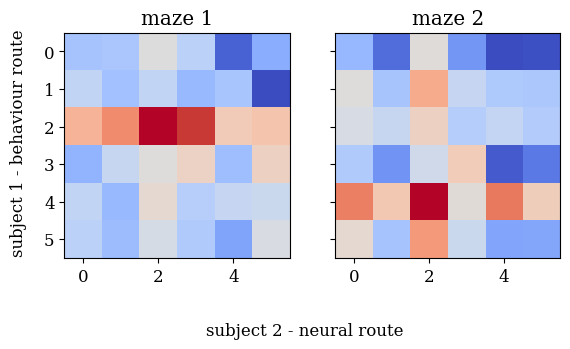

In [112]:
# beh_neu_corrs_normed = (beh_neu_corrs - beh_neu_corrs.mean(axis=-1, keepdims=True)) / beh_neu_corrs.std(axis=-1, keepdims=True)
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
for i in range(2):
    ax[i].imshow(beh_neu_corrs[i], cmap='coolwarm')
    ax[i].set_title(f'maze {i+1}')
fig.text(0.5, 0.1, 'subject 2 - neural route', ha='center')
fig.text(0.04, 0.5, 'subject 1 - behaviour route', va='center', rotation='vertical')
plt.show()

In [118]:
M1,M2 = beh_neu_corrs

#M1 = M2

print(np.round(M1, 2))

print(np.mean(np.diag(M1)))
print(np.mean(M1))

diff = np.mean(np.diag(M1) - np.mean(M1))

N = 10000

diffs = np.zeros(N)

for n in range(N):
    inds = np.random.choice(6, 6, replace = False)
    M1_shuff = M1[:, inds]
    diffs[n] = np.mean(np.diag(M1_shuff)) - np.mean(M1_shuff)
    
    
print(np.mean(diffs), np.std(diffs), np.mean(diffs > diff ))

[[0.37 0.37 0.39 0.38 0.34 0.36]
 [0.38 0.37 0.38 0.37 0.37 0.33]
 [0.41 0.42 0.45 0.44 0.4  0.4 ]
 [0.36 0.38 0.39 0.4  0.37 0.4 ]
 [0.38 0.36 0.39 0.37 0.38 0.38]
 [0.38 0.37 0.39 0.37 0.36 0.39]]
0.3919038907657992
0.3818502042458718
1.8120723858322613e-05 0.004851699744024568 0.0124
